# 17 — Classificação: dataset completo + limiares 500 / 730

Treinamento na **amostra total** (sem SAMPLE — ~13 M linhas de treino após exclusão de teste/val).  
Target redefinido diretamente de `NU_NOTA_MT`:

| Classe | Critério |
|--------|----------|
| **Baixo** | NU_NOTA_MT < 500 |
| **Medio** | 500 ≤ NU_NOTA_MT < 730 |
| **Alto**  | NU_NOTA_MT ≥ 730 |

**Pré-requisito:** notebooks 14 (`ml_features.parquet`, `test_set.parquet`, `val_set.parquet`) já executados.  
**⚠ Aviso:** tempo total de treino esperado: 2–5 h dependendo do hardware.

## 0. Imports e configuração

In [2]:
import warnings, time, gc
warnings.filterwarnings('ignore')

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.linear_model  import LogisticRegression, SGDClassifier
from sklearn.svm           import LinearSVC
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                   HistGradientBoostingClassifier,
                                   VotingClassifier)
from sklearn.pipeline      import Pipeline
from sklearn.impute        import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (classification_report, accuracy_score,
                                   f1_score, ConfusionMatrixDisplay)
from sklearn.base          import clone
from pathlib import Path

BASE       = Path('../data/processed')
ML_PARQUET = BASE / 'ml_features.parquet'
TEST_SET   = BASE / 'test_set.parquet'
VAL_SET    = BASE / 'val_set.parquet'
SEED       = 42
CLASS_3    = ['Baixo', 'Medio', 'Alto']
THRESH_LOW = 500    # abaixo → Baixo
THRESH_HIGH = 730   # acima (≥) → Alto

# Feature sets — idênticos aos notebooks anteriores
FEATS_M1 = [
    'REGIAO_NUM', 'TP_SEXO_NUM', 'TP_COR_RACA_NUM', 'TP_ESCOLA_NUM',
    'Q001_NUM', 'Q002_NUM', 'Q006_NUM',
    'Q_N_PESSOAS_NUM', 'Q_OCUP_PAI_NUM', 'Q_OCUP_MAE_NUM',
    'Q_EMPREGADA_NUM', 'Q_BANHEIRO_NUM', 'Q_QUARTO_NUM',
    'Q_CARRO_NUM', 'Q_MOTO_NUM', 'Q_GELADEIRA_NUM',
    'Q_FREEZER_NUM', 'Q_LAVADORA_NUM', 'Q_MICROONDAS_NUM', 'Q_IMPRESSORA_NUM',
    'Q_TV_NUM', 'Q_COMPUTADOR_NUM', 'Q_INTERNET_NUM', 'Q_CELULAR_NUM', 'Q_TEL_FIXO_NUM',
    'Q_TIPO_ESCOLA_EM_NUM', 'Q_BOLSA_FAM_NUM', 'Q_TRABALHA_NUM',
]
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil',
]
FEATS_PERS = ['idhm_cand_raca', 'idhm_cand_sexo']
FEATS_M2   = FEATS_M1 + FEATS_IDHM
FEATS_M3   = FEATS_M2 + FEATS_PERS
VARIANTS   = {'M1': FEATS_M1, 'M2': FEATS_M2, 'M3': FEATS_M3}

print(f'M1: {len(FEATS_M1)} | M2: {len(FEATS_M2)} | M3: {len(FEATS_M3)} features')
print(f'Limiares: Baixo < {THRESH_LOW} | Medio {THRESH_LOW}–{THRESH_HIGH} | Alto ≥ {THRESH_HIGH}')

M1: 28 | M2: 37 | M3: 39 features
Limiares: Baixo < 500 | Medio 500–730 | Alto ≥ 730


## 1. Carregamento — dataset completo (sem amostragem)

In [3]:
def nota_to_class(s: pd.Series) -> pd.Series:
    """Mapeia NU_NOTA_MT para Baixo/Medio/Alto com limiares 500/730."""
    out = pd.Series('Medio', index=s.index, dtype=object)
    out[s < THRESH_LOW]  = 'Baixo'
    out[s >= THRESH_HIGH] = 'Alto'
    return out

print('Carregando val e test fixos...')
df_val  = pd.read_parquet(VAL_SET)
df_test = pd.read_parquet(TEST_SET)

df_val['FAIXA_3C']  = nota_to_class(df_val['NU_NOTA_MT'])
df_test['FAIXA_3C'] = nota_to_class(df_test['NU_NOTA_MT'])

df_val  = df_val.dropna(subset=['NU_NOTA_MT'])
df_test = df_test.dropna(subset=['NU_NOTA_MT'])

excl_ids = pd.concat([df_val[['_row_id']], df_test[['_row_id']]])

con = duckdb.connect()
con.execute("SET memory_limit = '14GB'")
con.execute("SET threads = 8")
con.register('excl_ids', excl_ids)

print('Carregando treino completo (sem amostragem)...')
t0 = time.time()
df_train = con.execute(f"""
    SELECT *
    FROM read_parquet('{ML_PARQUET}')
    WHERE NU_NOTA_MT IS NOT NULL
      AND NU_ANO BETWEEN 2019 AND 2024
      AND _row_id NOT IN (SELECT _row_id FROM excl_ids)
""").df()
con.close()
print(f'Carregado em {time.time()-t0:.1f}s')

df_train['FAIXA_3C'] = nota_to_class(df_train['NU_NOTA_MT'])

print(f'\nTreino:  {len(df_train):>12,} linhas')
print(f'Val:     {len(df_val):>12,} linhas')
print(f'Teste:   {len(df_test):>12,} linhas (SELADO)')
print('\nDistribuição treino (NU_NOTA_MT < 500 / 500–730 / ≥730):')
print(df_train['FAIXA_3C'].value_counts(normalize=True).reindex(CLASS_3)
      .apply(lambda x: f'{x:.1%}'))

Carregando val e test fixos...
Carregando treino completo (sem amostragem)...
Carregado em 79.6s

Treino:    13,398,916 linhas
Val:        1,488,771 linhas
Teste:      1,654,191 linhas (SELADO)

Distribuição treino (NU_NOTA_MT < 500 / 500–730 / ≥730):
FAIXA_3C
Baixo    46.8%
Medio    47.5%
Alto      5.7%
Name: proportion, dtype: str


In [4]:
# float32 para economizar ~50% de memória RAM
TARGET = 'FAIXA_3C'
arrays = {}
for vname, feats in VARIANTS.items():
    X_tr = df_train[feats].astype('float32').values
    X_v  = df_val[feats].astype('float32').values
    X_te = df_test[feats].astype('float32').values
    arrays[vname] = (X_tr, X_v, X_te)
    nan_pct = np.isnan(X_tr).mean() * 100
    mem_gb  = X_tr.nbytes / 1e9
    print(f'{vname}: shape={X_tr.shape}  NaN={nan_pct:.1f}%  RAM≈{mem_gb:.2f} GB')

y_train = df_train[TARGET].values
y_val   = df_val[TARGET].values
y_test  = df_test[TARGET].values

# Libera o DataFrame após extrair arrays
del df_train
gc.collect()
print('\nDataFrame de treino removido da memória (arrays numpy mantidos).')

M1: shape=(13398916, 28)  NaN=4.1%  RAM≈1.50 GB
M2: shape=(13398916, 37)  NaN=20.5%  RAM≈1.98 GB
M3: shape=(13398916, 39)  NaN=23.2%  RAM≈2.09 GB

DataFrame de treino removido da memória (arrays numpy mantidos).


## 2. Algoritmo Genético — otimização de hiperparâmetros

Fitness avaliado num subconjunto de 50k amostras de treino (rápido, mesmos resultados).  
Os melhores parâmetros serão usados depois no treino completo.

In [5]:
GA_SUB   = 50_000
rng_sub  = np.random.default_rng(SEED)

X_m1_tr  = arrays['M1'][0]
idx_sub  = rng_sub.choice(len(X_m1_tr), size=min(GA_SUB, len(X_m1_tr)), replace=False)
idx_subv = rng_sub.choice(len(arrays['M1'][1]), size=min(15_000, len(arrays['M1'][1])), replace=False)

X_sub,    y_sub    = X_m1_tr[idx_sub],          y_train[idx_sub]
X_subval, y_subval = arrays['M1'][1][idx_subv], y_val[idx_subv]

print(f'Subset treino AG: {len(X_sub):,} | Subset val AG: {len(X_subval):,}')

def _tournament(pop, fits, k, rng):
    idx = rng.integers(0, len(pop), k)
    return pop[idx[np.argmax(fits[idx])]].copy()

def _crossover(p1, p2, rng):
    mask = rng.random(len(p1)) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)

def _mutate(ind, gene_min, gene_max, binary_mask, rng):
    ind = ind.copy()
    ranges = gene_max - gene_min
    for i in range(len(ind)):
        if binary_mask[i]:
            if rng.random() < 0.30: ind[i] = 1.0 - ind[i]
        else:
            if rng.random() < 0.40:
                ind[i] = np.clip(ind[i] + rng.normal(0, 0.15 * ranges[i]),
                                 gene_min[i], gene_max[i])
    return ind

def evolve_ag(gene_min, gene_max, fitness_fn, binary_mask,
              pop_size=20, n_gens=15, seed=SEED, label=''):
    rng = np.random.default_rng(seed)
    pop = np.column_stack([rng.uniform(gene_min[i], gene_max[i], pop_size)
                           for i in range(len(gene_min))])
    for i, b in enumerate(binary_mask):
        if b: pop[:, i] = np.round(pop[:, i])
    fits = np.array([fitness_fn(ind) for ind in pop])
    hist = [fits.max()]
    print(f'[{label}] Gen  0  best={fits.max():.4f}  mean={fits.mean():.4f}')
    for gen in range(1, n_gens + 1):
        elite   = list(pop[np.argsort(fits)[-2:]])
        new_pop = elite[:]
        while len(new_pop) < pop_size:
            p1 = _tournament(pop, fits, 3, rng)
            p2 = _tournament(pop, fits, 3, rng)
            c1, c2 = (_crossover(p1, p2, rng) if rng.random() < 0.70
                      else (p1.copy(), p2.copy()))
            if rng.random() < 0.25: c1 = _mutate(c1, gene_min, gene_max, binary_mask, rng)
            if rng.random() < 0.25: c2 = _mutate(c2, gene_min, gene_max, binary_mask, rng)
            new_pop.append(c1)
            if len(new_pop) < pop_size: new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([fitness_fn(ind) for ind in pop])
        hist.append(fits.max())
        print(f'[{label}] Gen {gen:2d}  best={fits.max():.4f}  mean={fits.mean():.4f}')
    return pop[fits.argmax()], fits.max(), hist

print('Componentes do AG prontos.')

Subset treino AG: 50,000 | Subset val AG: 15,000
Componentes do AG prontos.


In [6]:
def decode_lr(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_lr(ind):
    C, bal = decode_lr(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()),
                      ('clf', LogisticRegression(C=C, class_weight='balanced' if bal else None,
                                                 max_iter=300, solver='saga', n_jobs=-1, random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — Logistic Regression ===')
t0 = time.time()
best_lr_ind, _, ag_hist_lr = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_lr, binary_mask=[False, True], pop_size=20, n_gens=15, label='LR')
best_C_lr, best_bal_lr = decode_lr(best_lr_ind)
print(f'\nResultado: C={best_C_lr:.4f}, balanced={best_bal_lr}  ({(time.time()-t0)/60:.1f} min)')

=== AG — Logistic Regression ===
[LR] Gen  0  best=0.4182  mean=0.4150
[LR] Gen  1  best=0.4182  mean=0.4165
[LR] Gen  2  best=0.4182  mean=0.4167
[LR] Gen  3  best=0.4182  mean=0.4171
[LR] Gen  4  best=0.4182  mean=0.4172
[LR] Gen  5  best=0.4182  mean=0.4181
[LR] Gen  6  best=0.4182  mean=0.4181
[LR] Gen  7  best=0.4182  mean=0.4176
[LR] Gen  8  best=0.4182  mean=0.4179
[LR] Gen  9  best=0.4182  mean=0.4181
[LR] Gen 10  best=0.4182  mean=0.4179
[LR] Gen 11  best=0.4182  mean=0.4176
[LR] Gen 12  best=0.4182  mean=0.4179
[LR] Gen 13  best=0.4182  mean=0.4182
[LR] Gen 14  best=0.4182  mean=0.4181
[LR] Gen 15  best=0.4182  mean=0.4181

Resultado: C=0.0030, balanced=True  (7.4 min)


In [7]:
def decode_svm(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_svm(ind):
    C, bal = decode_svm(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()),
                      ('clf', LinearSVC(C=C, class_weight='balanced' if bal else None,
                                        max_iter=2000, dual='auto', random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — SVM (LinearSVC) ===')
t0 = time.time()
best_svm_ind, _, ag_hist_svm = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_svm, binary_mask=[False, True], pop_size=20, n_gens=15, label='SVM')
best_C_svm, best_bal_svm = decode_svm(best_svm_ind)
print(f'\nResultado: C={best_C_svm:.4f}, balanced={best_bal_svm}  ({(time.time()-t0)/60:.1f} min)')

=== AG — SVM (LinearSVC) ===
[SVM] Gen  0  best=0.4765  mean=0.4382
[SVM] Gen  1  best=0.4765  mean=0.4669
[SVM] Gen  2  best=0.4765  mean=0.4637
[SVM] Gen  3  best=0.4765  mean=0.4669
[SVM] Gen  4  best=0.4765  mean=0.4637
[SVM] Gen  5  best=0.4769  mean=0.4765
[SVM] Gen  6  best=0.4774  mean=0.4766
[SVM] Gen  7  best=0.4774  mean=0.4704
[SVM] Gen  8  best=0.4774  mean=0.4738
[SVM] Gen  9  best=0.4774  mean=0.4771
[SVM] Gen 10  best=0.4778  mean=0.4741
[SVM] Gen 11  best=0.4778  mean=0.4710
[SVM] Gen 12  best=0.4778  mean=0.4743
[SVM] Gen 13  best=0.4778  mean=0.4777
[SVM] Gen 14  best=0.4778  mean=0.4777
[SVM] Gen 15  best=0.4778  mean=0.4777

Resultado: C=0.0010, balanced=True  (3.7 min)


In [8]:
def decode_lgb(ind):
    return float(np.clip(ind[0], 0.01, 0.30)), int(round(np.clip(ind[1], 15, 127)))

def fitness_lgb(ind):
    lr, nl = decode_lgb(ind)
    try:
        m = lgb.LGBMClassifier(learning_rate=lr, num_leaves=nl,
                                n_estimators=200, max_depth=8,
                                n_jobs=-1, random_state=SEED, verbose=-1)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — LightGBM ===')
t0 = time.time()
best_lgb_ind, _, ag_hist_lgb = evolve_ag(
    np.array([0.01, 15.0]), np.array([0.30, 127.0]),
    fitness_lgb, binary_mask=[False, False], pop_size=15, n_gens=10, label='LGB')
best_lr_lgb, best_nl_lgb = decode_lgb(best_lgb_ind)
print(f'\nResultado: lr={best_lr_lgb:.4f}, num_leaves={best_nl_lgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — LightGBM ===
[LGB] Gen  0  best=0.4480  mean=0.4438
[LGB] Gen  1  best=0.4481  mean=0.4459
[LGB] Gen  2  best=0.4481  mean=0.4469
[LGB] Gen  3  best=0.4481  mean=0.4458
[LGB] Gen  4  best=0.4508  mean=0.4462
[LGB] Gen  5  best=0.4555  mean=0.4489
[LGB] Gen  6  best=0.4555  mean=0.4511
[LGB] Gen  7  best=0.4555  mean=0.4519
[LGB] Gen  8  best=0.4555  mean=0.4530
[LGB] Gen  9  best=0.4555  mean=0.4512
[LGB] Gen 10  best=0.4555  mean=0.4541

Resultado: lr=0.2889, num_leaves=55  (5.5 min)


In [9]:
def decode_hgb(ind):
    return float(np.clip(ind[0], 0.01, 0.30)), int(round(np.clip(ind[1], 3, 12)))

def fitness_hgb(ind):
    lr, md = decode_hgb(ind)
    try:
        m = HistGradientBoostingClassifier(learning_rate=lr, max_depth=md,
                                           max_iter=200, min_samples_leaf=50, random_state=SEED)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — HistGradientBoosting ===')
t0 = time.time()
best_hgb_ind, _, ag_hist_hgb = evolve_ag(
    np.array([0.01, 3.0]), np.array([0.30, 12.0]),
    fitness_hgb, binary_mask=[False, False], pop_size=15, n_gens=10, label='HGB')
best_lr_hgb, best_md_hgb = decode_hgb(best_hgb_ind)
print(f'\nResultado: lr={best_lr_hgb:.4f}, max_depth={best_md_hgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — HistGradientBoosting ===
[HGB] Gen  0  best=0.4545  mean=0.4380
[HGB] Gen  1  best=0.4545  mean=0.4440
[HGB] Gen  2  best=0.4562  mean=0.4513
[HGB] Gen  3  best=0.4562  mean=0.4531
[HGB] Gen  4  best=0.4574  mean=0.4543
[HGB] Gen  5  best=0.4574  mean=0.4549
[HGB] Gen  6  best=0.4574  mean=0.4564
[HGB] Gen  7  best=0.4574  mean=0.4568
[HGB] Gen  8  best=0.4574  mean=0.4551
[HGB] Gen  9  best=0.4574  mean=0.4535
[HGB] Gen 10  best=0.4574  mean=0.4565

Resultado: lr=0.2590, max_depth=7  (1.4 min)


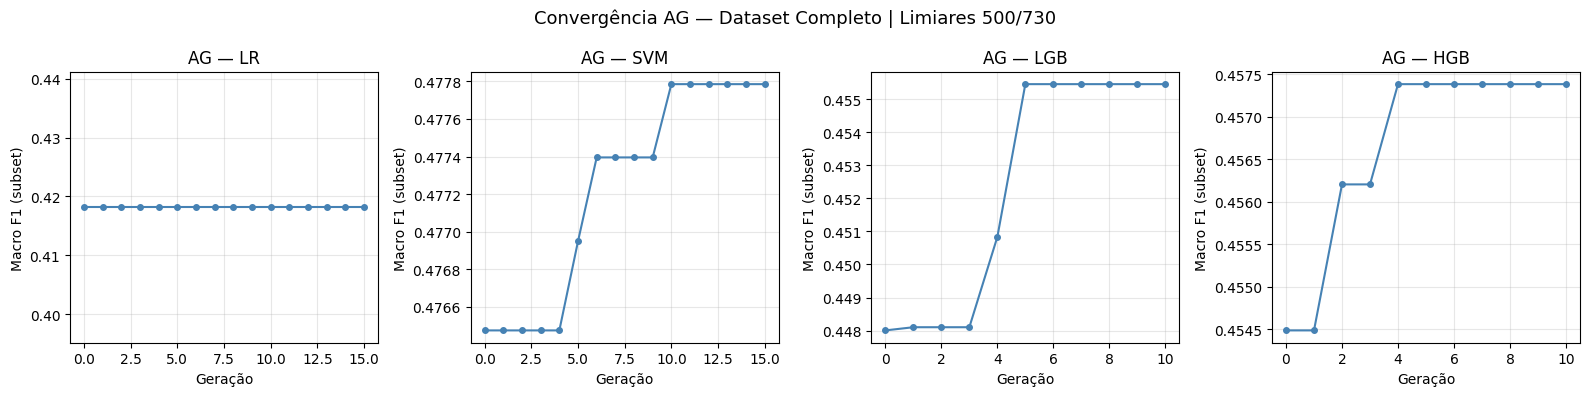

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nome, hist) in zip(axes, [
    ('LR', ag_hist_lr), ('SVM', ag_hist_svm),
    ('LGB', ag_hist_lgb), ('HGB', ag_hist_hgb)
]):
    ax.plot(range(len(hist)), hist, 'o-', color='steelblue', markersize=4)
    ax.set_title(f'AG — {nome}')
    ax.set_xlabel('Geração')
    ax.set_ylabel('Macro F1 (subset)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Convergência AG — Dataset Completo | Limiares 500/730', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/ag_convergencia_full.png', dpi=120)
plt.show()

## 3. Definição dos modelos

> **Nota sobre SVM em ensembles soft:** `LinearSVC` não emite probabilidades.  
> Para os ensembles de votação suave, usamos `SGDClassifier(loss='modified_huber')`, que é matematicamente equivalente (SVM de margem suave) e produz `predict_proba` nativamente, sendo muito mais eficiente em ~13 M amostras.

In [11]:
_imp = lambda: SimpleImputer(strategy='median')
_scl = lambda: StandardScaler()

modelos_base = {
    'LogisticRegression': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LogisticRegression(
            C=best_C_lr,
            class_weight='balanced' if best_bal_lr else None,
            max_iter=500, solver='saga', n_jobs=-1, random_state=SEED)),
    ]),
    'DecisionTree': Pipeline([
        ('imp', _imp()),
        ('clf', DecisionTreeClassifier(max_depth=12, min_samples_leaf=100, random_state=SEED)),
    ]),
    'RandomForest': Pipeline([
        ('imp', _imp()),
        # max_samples=0.3 — amostra 30% por árvore para viabilizar 13M linhas
        ('clf', RandomForestClassifier(
            n_estimators=80, max_depth=14, min_samples_leaf=100,
            max_samples=0.30, n_jobs=-1, random_state=SEED)),
    ]),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=best_lr_hgb, max_depth=best_md_hgb,
        max_iter=200, min_samples_leaf=100, random_state=SEED),
    'SVM (LinearSVC)': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LinearSVC(
            C=best_C_svm,
            class_weight='balanced' if best_bal_svm else None,
            max_iter=3000, dual='auto', random_state=SEED)),
    ]),
    'LightGBM': lgb.LGBMClassifier(
        learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=SEED, verbose=-1),
}

# SGD-SVM: equivalente ao LinearSVC para ensembles soft (dá predict_proba, escala para 13M)
def make_sgd_svm():
    return Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', SGDClassifier(
            loss='modified_huber',
            class_weight='balanced' if best_bal_svm else None,
            alpha=1e-4, max_iter=200, n_jobs=-1,
            random_state=SEED, early_stopping=False)),
    ])

def make_lgb_clone():
    return lgb.LGBMClassifier(
        learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=SEED, verbose=-1)

def make_rf_clone():
    return Pipeline([('imp', _imp()),
                     ('clf', RandomForestClassifier(
                         n_estimators=80, max_depth=14, min_samples_leaf=100,
                         max_samples=0.30, n_jobs=-1, random_state=SEED))])

def make_hgb_clone():
    return HistGradientBoostingClassifier(
        learning_rate=best_lr_hgb, max_depth=best_md_hgb,
        max_iter=200, min_samples_leaf=100, random_state=SEED)

ensembles_fixos = {
    'Ensemble SVM+LGB Hard': VotingClassifier(
        estimators=[('svm', clone(modelos_base['SVM (LinearSVC)'])),
                    ('lgb', make_lgb_clone())],
        voting='hard', n_jobs=1),
    'Ensemble SVM+LGB Soft': VotingClassifier(
        estimators=[('sgd', make_sgd_svm()), ('lgb', make_lgb_clone())],
        voting='soft', n_jobs=1),
    'Ensemble Full Soft': VotingClassifier(
        estimators=[('sgd', make_sgd_svm()), ('lgb', make_lgb_clone()),
                    ('rf',  make_rf_clone()), ('hgb', make_hgb_clone())],
        voting='soft', n_jobs=1),
}

print(f'Modelos base: {list(modelos_base.keys())}')
print(f'Ensembles:    {list(ensembles_fixos.keys())}')

Modelos base: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'SVM (LinearSVC)', 'LightGBM']
Ensembles:    ['Ensemble SVM+LGB Hard', 'Ensemble SVM+LGB Soft', 'Ensemble Full Soft']


## 4. Loop de treinamento × M1 / M2 / M3

⏱ **Estimativa de tempo total: 2–5 h** (LGB e HGB são rápidos; RF e SVM são os gargalos).

In [ ]:
all_results   = []
all_trained   = {}
top2_ensemble = None
top2_names    = None

for vname, feats in VARIANTS.items():
    X_tr, X_v, X_te = arrays[vname]
    print(f'\n{"="*65}')
    print(f'  Variante {vname} — {len(feats)} features  |  treino: {len(X_tr):,}')
    print(f'{"="*65}')

    modelos_v = {n: clone(m) for n, m in modelos_base.items()}
    modelos_v.update({n: clone(m) for n, m in ensembles_fixos.items()})
    if top2_ensemble is not None:
        modelos_v['Ensemble Top-2 Soft'] = clone(top2_ensemble)

    f1_scores_v = {}
    for nome, modelo in modelos_v.items():
        print(f'  {nome}...', end=' ', flush=True)
        t0 = time.time()
        modelo.fit(X_tr, y_train)
        t_tr = time.time() - t0

        y_pred = modelo.predict(X_v)
        acc  = accuracy_score(y_val, y_pred)
        f1_w = f1_score(y_val, y_pred, average='weighted', labels=CLASS_3, zero_division=0)
        f1_m = f1_score(y_val, y_pred, average='macro',    labels=CLASS_3, zero_division=0)

        all_results.append({'Variante': vname, 'Modelo': nome,
                            'Acurácia': acc, 'F1 Weighted': f1_w,
                            'F1 Macro': f1_m, 'Tempo (s)': round(t_tr, 1)})
        all_trained[(nome, vname)] = modelo
        f1_scores_v[nome] = f1_m
        print(f'acc={acc:.3f}  F1m={f1_m:.3f}  F1w={f1_w:.3f}  ({t_tr:.0f}s)')

    if vname == 'M1' and top2_ensemble is None:
        base_f1    = {n: f1_scores_v[n] for n in modelos_base.keys()}
        top2_names = sorted(base_f1, key=base_f1.get, reverse=True)[:2]
        print(f'\n  Top-2 identificados: {top2_names}')
        def _wrap(name):
            return make_sgd_svm() if 'SVM' in name else clone(modelos_base[name])
        top2_ensemble = VotingClassifier(
            estimators=[(n.replace(' ', '_').replace('(', '').replace(')', ''), _wrap(n))
                        for n in top2_names],
            voting='soft', n_jobs=1)

df_res = pd.DataFrame(all_results)
print('\n=== RESUMO — F1 Macro (Validação) ===')
pivot = df_res.pivot_table(index='Modelo', columns='Variante', values='F1 Macro', aggfunc='first')
print(pivot.round(4).to_string())


  Variante M1 — 28 features  |  treino: 13,398,916
  LogisticRegression... 

acc=0.480  F1m=0.419  F1w=0.492  (4031s)
  DecisionTree... acc=0.613  F1m=0.431  F1w=0.597  (150s)
  RandomForest... acc=0.617  F1m=0.427  F1w=0.599  (320s)
  HistGradientBoosting... acc=0.621  F1m=0.443  F1w=0.606  (449s)
  SVM (LinearSVC)... 

## 5. Visualização dos resultados

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
pivot_sorted = pivot.loc[pivot.mean(axis=1).sort_values(ascending=True).index]
pivot_sorted.plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('F1 Macro')
ax.set_title('F1 Macro por Modelo — Dataset Completo | Limiares 500/730')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

ax2 = axes[1]
if all(v in pivot.columns for v in ['M1', 'M2', 'M3']):
    delta = pd.DataFrame({
        'ΔF1: M2−M1 (IDHM)':         pivot['M2'] - pivot['M1'],
        'ΔF1: M3−M2 (IDHM pessoal)': pivot['M3'] - pivot['M2'],
    }).sort_values('ΔF1: M2−M1 (IDHM)')
    delta.plot(kind='barh', ax=ax2, width=0.7, color=['steelblue', 'darkorange'])
    ax2.axvline(0, color='k', linewidth=0.8)
    ax2.set_xlabel('ΔF1 Macro')
    ax2.set_title('Impacto do IDHM — Dataset Completo')
    ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/classificacao_resultados_full.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop-5 modelos por F1 Macro:')
print(df_res.nlargest(5, 'F1 Macro')[['Variante','Modelo','F1 Macro','F1 Weighted','Acurácia','Tempo (s)']].to_string(index=False))

## 6. Relatório do melhor modelo

In [ ]:
best_row   = df_res.loc[df_res['F1 Macro'].idxmax()]
best_nome  = best_row['Modelo']
best_var   = best_row['Variante']
best_model = all_trained[(best_nome, best_var)]

X_v_best    = arrays[best_var][1]
y_pred_best = best_model.predict(X_v_best)

print(f'Melhor: {best_nome} ({best_var}) — F1 Macro={best_row["F1 Macro"]:.4f}\n')
print(classification_report(y_val, y_pred_best, labels=CLASS_3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_best, labels=CLASS_3,
    normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
ax.set_title(f'{best_nome} ({best_var})\nDataset Completo | Limiares 500/730 | Validação')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_full_best.png', dpi=120)
plt.show()

## 6b. Matrizes de Confusão — todos os modelos (melhor variante)

In [ ]:
modelos_ordem = df_res[df_res['Variante'] == best_var].sort_values('F1 Macro', ascending=False)['Modelo'].tolist()
n_mod  = len(modelos_ordem)
n_cols = 5
n_rows = (n_mod + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.ravel()

for idx, nome in enumerate(modelos_ordem):
    ax = axes[idx]
    m  = all_trained.get((nome, best_var))
    if m is None: ax.set_visible(False); continue
    yp  = m.predict(arrays[best_var][1])
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
    ax.set_title(f'{nome}\nF1m={f1m:.3f}', fontsize=9)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xlabel('Previsto', fontsize=7)
    ax.set_ylabel('Real', fontsize=7)

for ax in axes[n_mod:]: ax.set_visible(False)

plt.suptitle(f'Matrizes de Confusão — Variante {best_var} | Dataset Completo | Limiares 500/730', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices_full_todos.png', dpi=120, bbox_inches='tight')
plt.show()

## 6c. Matrizes de Confusão — melhor modelo × M1 / M2 / M3

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vname in zip(axes, ['M1', 'M2', 'M3']):
    m = all_trained.get((best_nome, vname))
    if m is None: ax.set_visible(False); continue
    yp  = m.predict(arrays[vname][1])
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    acc = accuracy_score(y_val, yp)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
    ax.set_title(f'{best_nome} — {vname}\nF1m={f1m:.3f}  acc={acc:.3f}', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)
plt.suptitle(f'Impacto do IDHM — {best_nome} | Dataset Completo | Limiares 500/730', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_full_m1m2m3.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Importância das features

In [ ]:
tree_models = ['RandomForest', 'HistGradientBoosting', 'LightGBM', 'DecisionTree']
feats = VARIANTS[best_var]

importances = {}
for nome in tree_models:
    m = all_trained.get((nome, best_var))
    if m is None: continue
    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m
    if hasattr(clf, 'feature_importances_'):
        importances[nome] = clf.feature_importances_

if importances:
    n_plt = min(3, len(importances))
    fig, axes = plt.subplots(1, n_plt, figsize=(6 * n_plt, 6))
    if n_plt == 1: axes = [axes]
    for ax, (nome, imp) in zip(axes, list(importances.items())[:n_plt]):
        top = np.argsort(imp)[::-1][:15]
        ax.barh([feats[i] for i in top[::-1]], imp[top[::-1]], color='steelblue')
        ax.set_title(f'{nome} ({best_var})')
        ax.set_xlabel('Importância')
        ax.tick_params(axis='y', labelsize=8)
    plt.suptitle(f'Top-15 Features | {best_var} | Dataset Completo', fontsize=13)
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importances_full.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8. Acurácia por região (hipótese H1)

In [ ]:
REGIAO_MAP = {0: 'Norte', 1: 'Nordeste', 2: 'Centro-Oeste', 3: 'Sudeste', 4: 'Sul'}

df_ev = df_val[['REGIAO_NUM', 'FAIXA_3C']].copy()
df_ev['y_pred'] = y_pred_best
df_ev['acerto'] = (df_ev['y_pred'] == df_ev['FAIXA_3C']).astype(int)

acc_reg = (
    df_ev.dropna(subset=['REGIAO_NUM'])
    .groupby('REGIAO_NUM')['acerto']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Acurácia', 'count': 'N'})
)
acc_reg.index = acc_reg.index.map(REGIAO_MAP)
acc_reg['Acurácia'] = acc_reg['Acurácia'].apply(lambda x: f'{x:.3f}')
acc_reg['N']        = acc_reg['N'].apply(lambda x: f'{x:,}')
print(f'Acurácia por região — {best_nome} ({best_var}) | Dataset Completo | Limiares 500/730:')
print(acc_reg.to_string())

## 9. ⚠️ Conjunto de TESTE — SELADO

**Descomentar apenas na entrega final.**

In [ ]:
# ── DESCOMENTE APENAS NA ENTREGA FINAL ──────────────────────────────────────
#
# X_te_best   = arrays[best_var][2]
# y_pred_test = best_model.predict(X_te_best)
# acc_test    = accuracy_score(y_test, y_pred_test)
# f1_test     = f1_score(y_test, y_pred_test, average='macro',
#                        labels=CLASS_3, zero_division=0)
# print(f'TESTE — {best_nome} ({best_var}) | Dataset Completo | Limiares 500/730')
# print(f'Acurácia: {acc_test:.4f}  |  F1 Macro: {f1_test:.4f}')
# print(classification_report(y_test, y_pred_test, labels=CLASS_3, zero_division=0))
#
# ─────────────────────────────────────────────────────────────────────────────
print('Teste selado. Descomentar somente na entrega final.')